First 5 rows of the dataframe:                               Region                Country        Item Type  \
0              Australia and Oceania                 Tuvalu        Baby Food   
1  Central America and the Caribbean                Grenada           Cereal   
2                             Europe                 Russia  Office Supplies   
3                 Sub-Saharan Africa  Sao Tome and Principe           Fruits   
4                 Sub-Saharan Africa                 Rwanda  Office Supplies   

  Sales Channel Order Priority Order Date   Order ID  Ship Date  Units Sold  \
0       Offline              H  5/28/2010  669165933  6/27/2010        9925   
1        Online              C  8/22/2012  963881480  9/15/2012        2804   
2       Offline              L   5/2/2014  341417157   5/8/2014        1779   
3        Online              C  6/20/2014  514321792   7/5/2014        8102   
4       Offline              L   2/1/2013  115456712   2/6/2013        5062   

   Unit Price

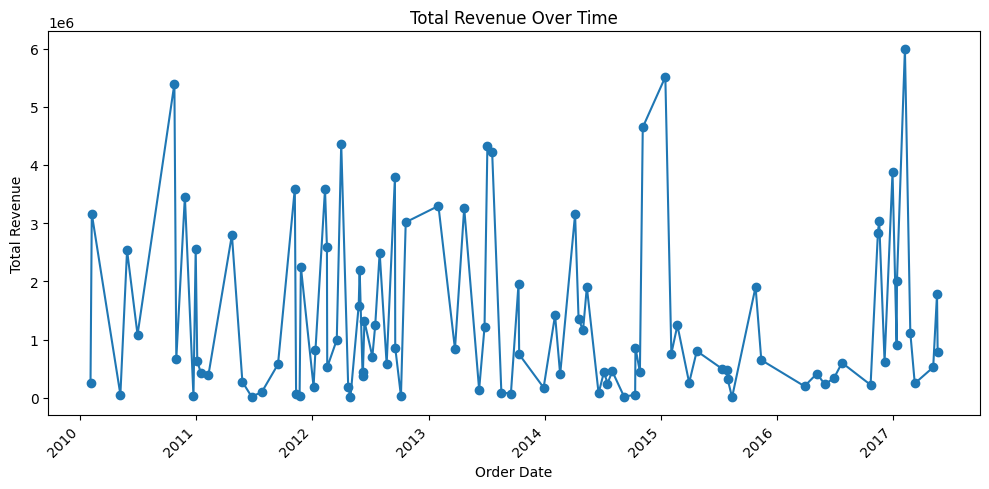

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url ="https://gist.githubusercontent.com/denandreychuk/b9aa812f10e4b60368cff69c6384a210/raw/100%20Sales%20Records.csv"
df = pd.read_csv(url)

# Display the first 5 rows of the dataframe
print(f"First 5 rows of the dataframe: {df.head()}")

#dataset info
print(f"\nDataset Information: {df.info()}")

# Check for missing values
print(f"\nMissing values in each column: {df.isnull().sum()}")

#cleaning data
print(f"number of dropped rows: {df.dropna().shape[0] - df.shape[0]}")   #number of rows with missing values


print(f"Basic statistics of numerical columns:\n {df.describe()}")


# Convert Order Date to datetime for time-series
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 1. Line Chart - Sales trend over time
# Set the figure size for the plot
plt.figure(figsize=(10,5))

# Group data by 'Order Date' and sum 'Total Revenue' for each date
sales_over_time = df.groupby('Order Date')['Total Revenue'].sum()

# Plot the sales trend as a line chart with markers
sales_over_time.plot(kind='line', marker='o')

# Set the title and axis labels
plt.title("Total Revenue Over Time")
plt.xlabel("Order Date")
plt.ylabel("Total Revenue")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent label overlap
plt.tight_layout()

# Display the plot
plt.show()


# 2. Bar Chart - Average Units Sold by Item Type
plt.figure(figsize=(10,5))
avg_units = df.groupby('Item Type')['Units Sold'].mean().sort_values()
avg_units.plot(kind='bar', color='skyblue')
plt.title("Average Units Sold by Item Type")
plt.xlabel("Item Type")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Histogram - Distribution of Total Profit
plt.figure(figsize=(8,5))
plt.hist(df['Total Profit'], bins=20, color='green', edgecolor='black')
plt.title("Distribution of Total Profit")
plt.xlabel("Total Profit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 4. Scatter Plot - Units Sold vs Total Profit
plt.figure(figsize=(8,5))
plt.scatter(df['Units Sold'], df['Total Profit'], alpha=0.6, color='purple')
plt.title("Units Sold vs Total Profit")
plt.xlabel("Units Sold")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()


